In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
dataset_path = "dataset"

IMG_SIZE = (160,160)
BATCH_SIZE = 64
EPOCHS = 30

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

num_classes = train_data.num_classes

Found 8000 images belonging to 5 classes.
Found 2000 images belonging to 5 classes.


In [5]:
base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [6]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_gesture_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
125/125 [==============================] - ETA: 0s - loss: 0.7935 - accuracy: 0.7237
Epoch 1: val_accuracy improved from -inf to 0.86850, saving model to best_gesture_model.keras
125/125 [==============================] - 84s 655ms/step - loss: 0.7935 - accuracy: 0.7237 - val_loss: 0.4325 - val_accuracy: 0.8685 - lr: 1.0000e-04
Epoch 2/30
125/125 [==============================] - ETA: 0s - loss: 0.1650 - accuracy: 0.9488
Epoch 2: val_accuracy improved from 0.86850 to 0.90550, saving model to best_gesture_model.keras
125/125 [==============================] - 80s 642ms/step - loss: 0.1650 - accuracy: 0.9488 - val_loss: 0.2281 - val_accuracy: 0.9055 - lr: 1.0000e-04
Epoch 3/30
125/125 [==============================] - ETA: 0s - loss: 0.0808 - accuracy: 0.9784
Epoch 3: val_accuracy improved from 0.90550 to 0.91900, saving model to best_gesture_model.keras
125/125 [==============================] - 80s 644ms/step - loss: 0.0808 - accuracy: 0.9784 - val_loss: 0.1794 - val_accur

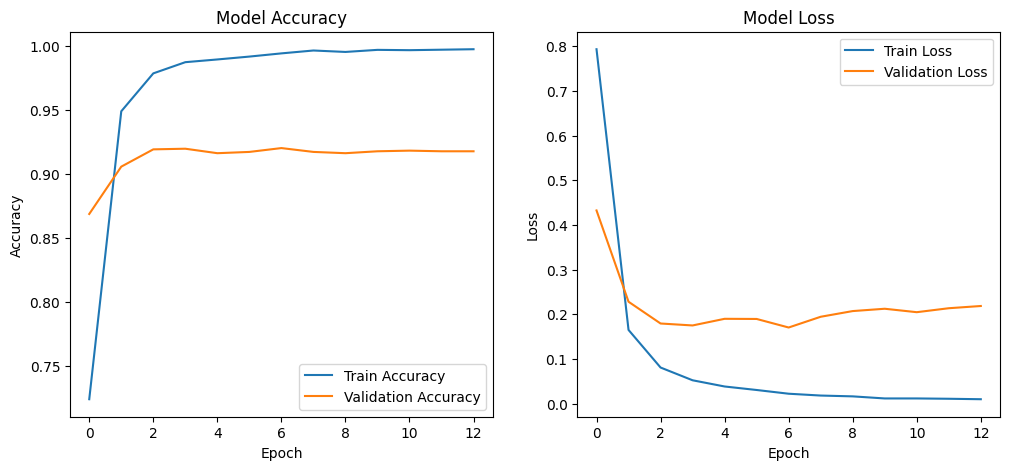

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [12]:
model.save("gesture_model_final.keras")